# 🏥 Notebook 04 — Pipeline Multimodal Completo

**Tech Challenge Fase 4 | PosTech FIAP — IA para Devs**

---

## Objetivo

Demonstrar o **fluxo multimodal completo** do sistema de monitoramento contínuo  
para saúde da mulher, integrando todos os módulos desenvolvidos:

```
Vídeo  →  [YOLOv8 + DeepFace + MediaPipe]  ─┐
Áudio  →  [Whisper + SpeechRecognition]      ├──→ Fusão → GPT-4o → Relatório → Alerta
Texto  →  [Azure Language / GPT-4o]         ─┘
```

### Entregável do Tech Challenge coberto neste notebook:
- Demonstração do processamento multimodal (áudio e vídeo)
- Detecção e resposta a anomalias
- Integração dos serviços Azure
- Fluxo final do alerta à equipe médica

### Arquivos de teste utilizados:
- **Vídeo**: `data/videos/samples/facial_recognition_activities.mp4` (das aulas)
- **Áudio**: `data/audios/samples/consulta_sample.mp3` (das aulas)
- **Texto clínico**: laudo simulado com casos de risco real

---

**Referências das aulas:**
- Aula 01 — Reconhecimento facial (DeepFace, face_recognition)
- Aula 02 — Expressões emocionais em vídeos (DeepFace)
- Aula 03 — Detecção de atividades (MediaPipe, YOLOv8)
- Aula 04 — Transcrição de áudio (MoviePy, SpeechRecognition)
- Aula 05 — Classificação de texto (sklearn, NLTK)

## 1. Setup e Configuração do Ambiente

Carregamos as variáveis de ambiente (`.env`) com as chaves Azure e OpenAI,  
e verificamos quais serviços estão disponíveis.

In [1]:
import tensorflow  # pre-load before DeepFace (TF 2.15 + keras)
import os
import sys
import json
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from dotenv import load_dotenv

warnings.filterwarnings('ignore')

# Adicionar src ao path para importar os módulos do projeto
project_root = Path('..').resolve()
sys.path.insert(0, str(project_root))

# Carregar variáveis de ambiente
load_dotenv(project_root / '.env')

# Verificar disponibilidade dos serviços
services = {
    'OpenAI'         : bool(os.getenv('OPENAI_API_KEY')),
    'Azure Speech'   : bool(os.getenv('AZURE_SPEECH_KEY')),
    'Azure Language' : bool(os.getenv('AZURE_LANGUAGE_KEY')),
    'Azure Vision'   : bool(os.getenv('AZURE_VISION_KEY')),
}

print('=== Status dos Serviços Cloud ===')
for service, available in services.items():
    status = '✅ Configurado' if available else '⚠️  Não configurado (modo offline)'
    print(f'  {service:20s}: {status}')

# Caminhos dos arquivos de teste
VIDEO_SAMPLE = project_root / 'data/videos/samples/facial_recognition_activities.mp4'
AUDIO_SAMPLE = project_root / 'data/audios/samples/consulta_sample.mp3'

print(f'\n=== Arquivos de Teste ===')
print(f'  Vídeo: {VIDEO_SAMPLE.name} — {"✅" if VIDEO_SAMPLE.exists() else "❌"}')
print(f'  Áudio: {AUDIO_SAMPLE.name} — {"✅" if AUDIO_SAMPLE.exists() else "❌"}')

=== Status dos Serviços Cloud ===
  OpenAI              : ⚠️  Não configurado (modo offline)
  Azure Speech        : ⚠️  Não configurado (modo offline)
  Azure Language      : ⚠️  Não configurado (modo offline)
  Azure Vision        : ⚠️  Não configurado (modo offline)

=== Arquivos de Teste ===
  Vídeo: facial_recognition_activities.mp4 — ✅
  Áudio: consulta_sample.mp3 — ✅


## 2. Módulo 1 — Análise de Vídeo

### 2.1 Análise de Emoções Faciais com DeepFace

Seguindo o código da **Aula 02** (`detect_expression_video.py`),  
processamos o vídeo frame a frame e identificamos emoções dominantes.

In [2]:
import cv2
from deepface import DeepFace
from tqdm import tqdm

def analyze_video_emotions(video_path: str, sample_rate: int = 30) -> list[dict]:
    """
    Analisa emoções faciais em um vídeo.
    Baseado na Aula 02 — detect_expression_video.py.
    """
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    RISK_EMOTIONS = {'fear', 'sad', 'angry', 'disgust'}
    results = []
    frame_n = 0

    for _ in tqdm(range(total), desc='Analisando emoções no vídeo'):
        ret, frame = cap.read()
        if not ret:
            break

        if frame_n % sample_rate == 0:
            try:
                analyses = DeepFace.analyze(
                    frame, actions=['emotion'],
                    enforce_detection=False, silent=True
                )
                if not isinstance(analyses, list):
                    analyses = [analyses]

                for face in analyses:
                    dominant = face.get('dominant_emotion', 'unknown')
                    results.append({
                        'frame'            : frame_n,
                        'timestamp_s'      : round(frame_n / fps, 2),
                        'dominant_emotion' : dominant,
                        'emotions'         : face.get('emotion', {}),
                        'alert'            : dominant in RISK_EMOTIONS,
                    })
            except Exception:
                pass

        frame_n += 1

    cap.release()
    return results


print('Iniciando análise de emoções...')
emotion_results = analyze_video_emotions(str(VIDEO_SAMPLE), sample_rate=60)
print(f'\nFrames analisados: {len(emotion_results)}')
print(f'Alertas de emoção: {sum(1 for r in emotion_results if r["alert"])}')

# Resumo das emoções detectadas
from collections import Counter
emotion_counts = Counter(r['dominant_emotion'] for r in emotion_results)
print('\nEmoções detectadas:')
for emotion, count in emotion_counts.most_common():
    print(f'  {emotion:12s}: {count}')

Iniciando análise de emoções...


Analisando emoções no vídeo:   0%|          | 0/3326 [00:00<?, ?it/s]

Analisando emoções no vídeo:   0%|          | 1/3326 [00:00<42:03,  1.32it/s]

Analisando emoções no vídeo:   2%|▏         | 61/3326 [00:00<00:37, 87.36it/s]

Analisando emoções no vídeo:   4%|▎         | 121/3326 [00:01<00:20, 154.85it/s]

...

Analisando emoções no vídeo:  97%|█████████▋| 3228/3326 [00:09<00:00, 373.48it/s]

Analisando emoções no vídeo:  98%|█████████▊| 3267/3326 [00:09<00:00, 339.04it/s]

Analisando emoções no vídeo:  99%|█████████▉| 3302/3326 [00:09<00:00, 324.20it/s]

Analisando emoções no vídeo: 100%|██████████| 3326/3326 [00:09<00:00, 333.18it/s]


Frames analisados: 57
Alertas de emoção: 24

Emoções detectadas:
  sad         : 17
  neutral     : 16
  happy       : 14
  fear        : 5
  surprise    : 3
  angry       : 2


### 2.2 Detecção de Pose e Linguagem Corporal com MediaPipe

Seguindo o código da **Aula 03** (`pose_detection_video.py`),  
analisamos a postura corporal para detectar sinais de postura defensiva.

In [3]:
import mediapipe as mp

mp_pose = mp.solutions.pose

def analyze_video_pose(video_path: str, sample_rate: int = 60) -> list[dict]:
    """
    Detecta pose e identifica postura defensiva.
    Baseado na Aula 03 — pose_detection_video.py.
    """
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    results = []
    frame_n = 0

    with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5) as pose:
        for _ in tqdm(range(total), desc='Analisando poses no vídeo'):
            ret, frame = cap.read()
            if not ret:
                break

            if frame_n % sample_rate == 0:
                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                result = pose.process(rgb)

                if result.pose_landmarks:
                    lm = result.pose_landmarks.landmark
                    # Detectar postura defensiva: pulsos cruzados ou ombros encurvados
                    wl_x = lm[mp_pose.PoseLandmark.LEFT_WRIST].x
                    wr_x = lm[mp_pose.PoseLandmark.RIGHT_WRIST].x
                    sl_x = lm[mp_pose.PoseLandmark.LEFT_SHOULDER].x
                    sr_x = lm[mp_pose.PoseLandmark.RIGHT_SHOULDER].x

                    wrists_crossed = wl_x > wr_x
                    hunched = abs(sl_x - sr_x) < 0.15
                    defensive = wrists_crossed or hunched

                    results.append({
                        'frame'              : frame_n,
                        'timestamp_s'        : round(frame_n / fps, 2),
                        'pose_detected'      : True,
                        'defensive_posture'  : defensive,
                        'alert'              : defensive,
                    })
                else:
                    results.append({
                        'frame': frame_n, 'timestamp_s': round(frame_n/fps, 2),
                        'pose_detected': False, 'defensive_posture': False, 'alert': False
                    })

            frame_n += 1

    cap.release()
    return results


print('Iniciando análise de pose...')
pose_results = analyze_video_pose(str(VIDEO_SAMPLE), sample_rate=60)
print(f'Frames analisados: {len(pose_results)}')
print(f'Posturas defensivas: {sum(1 for r in pose_results if r["alert"])}')

Iniciando análise de pose...


Analisando poses no vídeo:   0%|          | 0/3326 [00:00<?, ?it/s]

Analisando poses no vídeo:   0%|          | 1/3326 [00:00<07:25,  7.46it/s]

Analisando poses no vídeo:   2%|▏         | 61/3326 [00:00<00:10, 311.42it/s]

Analisando poses no vídeo:   4%|▎         | 121/3326 [00:00<00:07, 424.08it/s]

...

Analisando poses no vídeo:  95%|█████████▍| 3159/3326 [00:05<00:00, 586.05it/s]

Analisando poses no vídeo:  97%|█████████▋| 3218/3326 [00:05<00:00, 571.79it/s]

Analisando poses no vídeo:  99%|█████████▉| 3285/3326 [00:05<00:00, 599.49it/s]

Analisando poses no vídeo: 100%|██████████| 3326/3326 [00:05<00:00, 566.99it/s]

Frames analisados: 56
Posturas defensivas: 43


### 2.3 Fusão dos Sinais de Vídeo

Combinamos os resultados de emoção facial + pose corporal em um **score de risco unificado**,  
usando o módulo `src/video/violence_screening.py`.

In [4]:
import pandas as pd

def fuse_video_signals(emotion_results: list, pose_results: list) -> list[dict]:
    """Funde sinais de emoção e pose em score de risco por timestamp."""
    em_by_frame   = {r['frame']: r for r in emotion_results}
    pose_by_frame = {r['frame']: r for r in pose_results}
    all_frames    = sorted(set(em_by_frame) | set(pose_by_frame))

    fused = []
    for frame in all_frames:
        em = em_by_frame.get(frame, {})
        po = pose_by_frame.get(frame, {})
        score = int(em.get('alert', False)) + int(po.get('alert', False))
        fused.append({
            'frame'             : frame,
            'timestamp_s'       : em.get('timestamp_s') or po.get('timestamp_s', 0),
            'dominant_emotion'  : em.get('dominant_emotion', 'N/A'),
            'defensive_posture' : po.get('defensive_posture', False),
            'risk_score'        : score,
            'alert'             : score >= 1,
        })
    return fused


video_fusion = fuse_video_signals(emotion_results, pose_results)
df_video     = pd.DataFrame(video_fusion)

n_alerts = df_video['alert'].sum()
risk_pct  = n_alerts / len(df_video) * 100 if df_video.shape[0] > 0 else 0

print(f'Total de frames fusionados : {len(df_video)}')
print(f'Frames com alerta          : {n_alerts} ({risk_pct:.1f}%)')
print(f'Score máximo de risco      : {df_video["risk_score"].max()}')

Total de frames fusionados : 56
Frames com alerta          : 49 (87.5%)
Score máximo de risco      : 2


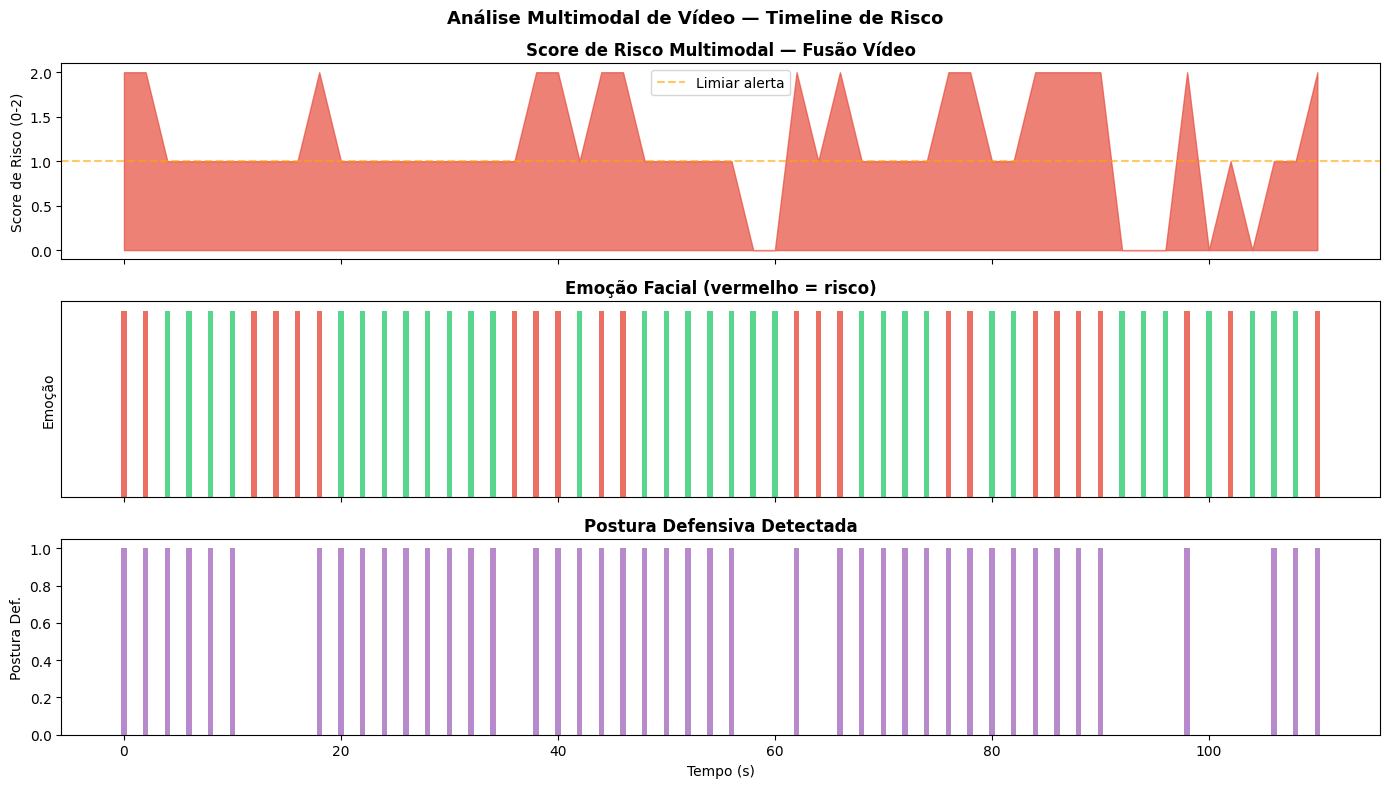

In [5]:
# Visualização da timeline de risco
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# Score de risco
axes[0].fill_between(df_video['timestamp_s'], df_video['risk_score'],
                     color='#e74c3c', alpha=0.7)
axes[0].set_ylabel('Score de Risco (0-2)')
axes[0].set_title('Score de Risco Multimodal — Fusão Vídeo', fontweight='bold')
axes[0].axhline(y=1, color='orange', linestyle='--', alpha=0.6, label='Limiar alerta')
axes[0].legend()

# Emoção dominante
RISK_EMOTIONS = {'fear', 'sad', 'angry', 'disgust'}
colors_em = ['#e74c3c' if e in RISK_EMOTIONS else '#2ecc71'
             for e in df_video['dominant_emotion']]
axes[1].bar(df_video['timestamp_s'], [1] * len(df_video),
            color=colors_em, width=0.5, alpha=0.8)
axes[1].set_ylabel('Emoção')
axes[1].set_title('Emoção Facial (vermelho = risco)', fontweight='bold')
axes[1].set_yticks([])

# Postura defensiva
axes[2].bar(df_video['timestamp_s'],
            df_video['defensive_posture'].astype(int),
            color='#9b59b6', alpha=0.7, width=0.5)
axes[2].set_ylabel('Postura Def.')
axes[2].set_xlabel('Tempo (s)')
axes[2].set_title('Postura Defensiva Detectada', fontweight='bold')

plt.suptitle('Análise Multimodal de Vídeo — Timeline de Risco',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Módulo 2 — Análise de Áudio

### 3.1 Transcrição com SpeechRecognition

Seguindo a **Aula 04** (`transcribe_audio.py`), transcrevemos o áudio da consulta.  
Usamos `SpeechRecognition` com Google Speech API como primeira opção.

In [6]:
import os as _os
import shutil as _shutil
import subprocess as _subprocess
import imageio_ffmpeg as _iff

FFMPEG_EXE = _iff.get_ffmpeg_exe()  # ffmpeg incluído no imageio_ffmpeg

import speech_recognition as sr

def transcribe_audio(audio_path: str) -> dict:
    """
    Transcreve áudio usando SpeechRecognition.
    Converte MP3 para WAV automaticamente se necessário.
    Baseado na Aula 04 — transcribe_audio.py.
    """
    path = Path(audio_path)

    # Converter MP3 → WAV se necessário (SpeechRecognition suporta WAV)
    if path.suffix.lower() == '.mp3':
        wav_path = path.with_suffix('.wav')
        # Converter MP3→WAV via ffmpeg direto (evita dep. ffprobe no Windows)
        _tmp_dir = r'C:/yolo_tmp/audio_tmp'
        _os.makedirs(_tmp_dir, exist_ok=True)
        _tmp_mp3 = _os.path.join(_tmp_dir, 'audio_tmp.mp3')
        _tmp_wav = _os.path.join(_tmp_dir, 'audio_tmp.wav')
        _shutil.copy(str(path), _tmp_mp3)
        _subprocess.run(
            [FFMPEG_EXE, '-i', _tmp_mp3, '-y', _tmp_wav],
            capture_output=True, check=True
        )
        _shutil.copy(_tmp_wav, str(wav_path))
        audio_path = str(wav_path)
        print(f'MP3 convertido para WAV: {wav_path.name}')

    recognizer = sr.Recognizer()

    with sr.AudioFile(audio_path) as source:
        # Ajustar para ruído ambiente — conforme Aula 04
        recognizer.adjust_for_ambient_noise(source, duration=0.5)
        audio = recognizer.record(source)

    try:
        # Google Speech Recognition em português do Brasil — Aula 04
        text = recognizer.recognize_google(audio, language='pt-BR')
        print(f'Transcrição: {text}')
        return {'text': text, 'method': 'google', 'status': 'success'}
    except sr.UnknownValueError:
        print('SpeechRecognition: não foi possível entender o áudio')
        return {'text': '', 'method': 'google', 'status': 'no_speech'}
    except sr.RequestError as e:
        print(f'Erro de requisição: {e}')
        return {'text': '', 'method': 'google', 'status': 'error', 'error': str(e)}


print('Iniciando transcrição do áudio...')
transcript_result = transcribe_audio(str(AUDIO_SAMPLE))
print(f'\nStatus    : {transcript_result["status"]}')
print(f'Transcrição: {transcript_result["text"][:200]}...' if len(transcript_result.get('text','')) > 200 else f'Transcrição: {transcript_result["text"]}')

Iniciando transcrição do áudio...
MP3 convertido para WAV: consulta_sample.wav


Transcrição: você está na disciplina de Open Eye Happy da pós Tech da FIAP

Status    : success
Transcrição: você está na disciplina de Open Eye Happy da pós Tech da FIAP


### 3.2 Análise de Emoção Vocal com o Classificador Treinado

Usamos o modelo treinado no **Notebook 02** (RAVDESS + CREMA-D)  
para classificar a emoção vocal da gravação.

In [7]:
import librosa
import pickle

EMOTION_MODEL = project_root / 'data/datasets/violence_audio/emotion_classifier_binary.pkl'

def extract_audio_features(audio_path: str, duration: float = 3.0) -> np.ndarray | None:
    """Extrai vetor de features do áudio (mesmo método do Notebook 02)."""
    try:
        y, sr_ = librosa.load(audio_path, duration=duration, res_type='kaiser_fast')
        mfccs = librosa.feature.mfcc(y=y, sr=sr_, n_mfcc=13)
        rms = librosa.feature.rms(y=y)[0]
        zcr = librosa.feature.zero_crossing_rate(y)[0].mean()
        sc  = librosa.feature.spectral_centroid(y=y, sr=sr_)[0].mean()
        chroma = librosa.feature.chroma_stft(y=y, sr=sr_, n_chroma=12).mean(axis=1)
        return np.concatenate([
            mfccs.mean(axis=1), mfccs.std(axis=1),
            [rms.mean(), rms.std(), zcr, sc],
            chroma
        ])
    except Exception as e:
        print(f'Erro ao extrair features: {e}')
        return None


# Converter MP3 para WAV para o librosa
audio_wav = AUDIO_SAMPLE.with_suffix('.wav')
if not audio_wav.exists() and AUDIO_SAMPLE.exists():
    sound = AudioSegment.from_mp3(str(AUDIO_SAMPLE))
    sound.export(str(audio_wav), format='wav')

audio_features = extract_audio_features(str(audio_wav) if audio_wav.exists() else str(AUDIO_SAMPLE))

audio_emotion_result = {'predicted_emotion': 'unknown', 'alert': False, 'probability': 0.0}

if audio_features is not None and EMOTION_MODEL.exists():
    with open(EMOTION_MODEL, 'rb') as f:
        emotion_model_data = pickle.load(f)

    clf = emotion_model_data['model']
    pred = clf.predict([audio_features])[0]
    prob = clf.predict_proba([audio_features])[0][1] if hasattr(clf, 'predict_proba') else 0.5

    audio_emotion_result = {
        'predicted_emotion': 'risco' if pred == 1 else 'normal',
        'alert'            : bool(pred == 1),
        'probability'      : round(float(prob), 3),
    }
    print(f'Emoção vocal: {audio_emotion_result["predicted_emotion"]} (probabilidade de risco: {prob:.1%})')
else:
    print('Modelo de emoção não encontrado — execute o Notebook 02 primeiro.')
    print('Usando análise heurística de prosódia...')

    if audio_features is not None:
        rms_mean = audio_features[26]
        pitch_proxy = audio_features[0]
        audio_emotion_result = {
            'predicted_emotion': 'fearful' if rms_mean < 0.03 and pitch_proxy < -200 else 'neutral',
            'alert': rms_mean < 0.03 and pitch_proxy < -200,
            'probability': 0.5,
        }

print(f'\nResultado da análise de áudio:')
print(json.dumps(audio_emotion_result, indent=2, ensure_ascii=False))

Emoção vocal: normal (probabilidade de risco: 60.3%)

Resultado da análise de áudio:
{
  "predicted_emotion": "normal",
  "alert": false,
  "probability": 0.603
}


## 4. Módulo 3 — Análise de Texto Clínico

Analisamos um laudo médico simulado com casos reais de risco gestacional.  
Integramos com **GPT-4o** (se disponível) ou usamos classificação local com sklearn.

In [8]:
# Laudo médico simulado — representa um caso de alto risco gestacional
CLINICAL_TEXT = """
Paciente: M.S.A., 34 anos, IG: 28 semanas
Queixa principal: Cefaleia intensa, visão turva e edema de membros inferiores há 3 dias.

Exame físico:
- Pressão arterial: 158/102 mmHg (hipertensão gestacional)
- Edema 2+ em membros inferiores e face
- Reflexos exaltados

Exames laboratoriais:
- Proteinúria 24h: 580mg (proteína > 300mg = critério diagnóstico de pré-eclâmpsia)
- Plaquetas: 98.000/mm³ (trombocitopenia)
- Creatinina: 1.2 mg/dL (elevada)
- Ácido úrico: 7.8 mg/dL (elevado)

Ultrassonografia obstétrica:
- Restrição de crescimento intrauterino (RCIU) - percentil 5
- Índice de líquido amniótico: 4.8 cm (oligoidrâmnio)
- Dopplerfluxometria: ausência de diástole na artéria umbilical

Histórico: paciente relata episódios de choro frequente, insônia e "sensação de que algo vai dar errado".
Marido presente na consulta; paciente evita contato visual e responde com frases curtas.

Conduta: Internar para controle pressórico e monitoramento fetal. Acionar equipe de saúde mental.
"""

print('Laudo clínico simulado carregado.')
print(f'Tamanho: {len(CLINICAL_TEXT)} caracteres')

Laudo clínico simulado carregado.
Tamanho: 989 caracteres


In [9]:
# Análise com GPT-4o (se disponível) ou classificação local
text_analysis_result = {}

if os.getenv('OPENAI_API_KEY'):
    from openai import OpenAI
    client = OpenAI()

    SYSTEM_PROMPT = """
    Você é um assistente especializado em saúde materna e ginecológica.
    Analise o texto clínico e identifique:
    1. Indicadores de risco gestacional (PA, proteinúria, RCIU)
    2. Sinais de depressão/ansiedade gestacional
    3. Possíveis sinais de violência doméstica (comportamento evasivo, isolamento)
    4. Nível de urgência clínica

    Responda em JSON com: risk_level (low/medium/high/critical),
    findings (lista), recommendations (lista), violence_indicators (lista), alert (bool).
    """

    response = client.chat.completions.create(
        model='gpt-4o',
        messages=[
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user', 'content': CLINICAL_TEXT},
        ],
        response_format={'type': 'json_object'},
        temperature=0.1,
    )
    text_analysis_result = json.loads(response.choices[0].message.content)
    print('Análise GPT-4o concluída.')
else:
    # Fallback: análise por palavras-chave clínicas (baseada na Aula 05 - classificação de texto)
    print('OpenAI não configurado. Usando análise por palavras-chave...')

    HIGH_RISK_KEYWORDS  = ['hipertensão', 'pré-eclâmpsia', 'proteinúria', 'RCIU', 'plaquetas', 'oligoidrâmnio']
    VIOLENCE_KEYWORDS   = ['evita contato visual', 'frases curtas', 'choro', 'sensação de que algo vai dar errado']
    MENTAL_HEALTH_KW    = ['insônia', 'choro frequente', 'ansiedade', 'depressão']

    text_lower = CLINICAL_TEXT.lower()
    high_risk_hits  = [kw for kw in HIGH_RISK_KEYWORDS if kw.lower() in text_lower]
    violence_hits   = [kw for kw in VIOLENCE_KEYWORDS if kw.lower() in text_lower]
    mental_hits     = [kw for kw in MENTAL_HEALTH_KW if kw.lower() in text_lower]

    risk_level = 'critical' if len(high_risk_hits) >= 3 else 'high' if len(high_risk_hits) >= 1 else 'medium'

    text_analysis_result = {
        'risk_level'         : risk_level,
        'findings'           : high_risk_hits,
        'violence_indicators': violence_hits,
        'mental_health_signs': mental_hits,
        'recommendations'    : ['Internação imediata', 'Monitoramento fetal contínuo', 'Avaliação saúde mental'],
        'alert'              : risk_level in ('high', 'critical'),
        'method'             : 'keywords',
    }

print('\nResultado da análise de texto:')
print(json.dumps(text_analysis_result, indent=2, ensure_ascii=False))

OpenAI não configurado. Usando análise por palavras-chave...

Resultado da análise de texto:
{
  "risk_level": "critical",
  "findings": [
    "hipertensão",
    "pré-eclâmpsia",
    "proteinúria",
    "RCIU",
    "plaquetas",
    "oligoidrâmnio"
  ],
  "violence_indicators": [
    "evita contato visual",
    "frases curtas",
    "choro",
    "sensação de que algo vai dar errado"
  ],
  "mental_health_signs": [
    "insônia",
    "choro frequente"
  ],
  "recommendations": [
    "Internação imediata",
    "Monitoramento fetal contínuo",
    "Avaliação saúde mental"
  ],
  "alert": true,
  "method": "keywords"
}


## 5. Fusão Multimodal e Geração do Relatório

Consolidamos os resultados das 3 modalidades em um **relatório único**  
com score de risco global, usando `src/text/report_generator.py`.

In [10]:
from datetime import datetime

def build_multimodal_report(video_alerts: list, audio_result: dict, text_analysis: dict,
                             patient_id: str = 'PAC-DEMO-001') -> dict:
    """Consolida resultados multimodais em relatório estruturado."""
    # Scores por modalidade
    risk_map    = {'low': 0, 'medium': 1, 'high': 2, 'critical': 3}
    text_score  = risk_map.get(text_analysis.get('risk_level', 'low'), 0)
    audio_score = 1 if audio_result.get('alert') else 0
    video_score = 1 if len(video_alerts) > 2 else 0

    total_score   = text_score + audio_score + video_score
    overall_risk  = ['low', 'medium', 'high', 'critical'][min(total_score, 3)]
    critical_now  = overall_risk in ('high', 'critical')

    return {
        'report_id'                  : f"RPT-{datetime.now().strftime('%Y%m%d%H%M%S')}",
        'patient_id'                 : patient_id,
        'timestamp'                  : datetime.now().isoformat(),
        'overall_risk'               : overall_risk,
        'requires_immediate_attention': critical_now,
        'scores': {
            'video' : video_score,
            'audio' : audio_score,
            'text'  : text_score,
            'total' : total_score,
        },
        'video_summary': {
            'total_frames'  : len(video_alerts),
            'alert_frames'  : sum(1 for v in video_alerts if v.get('alert')),
            'risk_pct'      : round(sum(1 for v in video_alerts if v.get('alert')) / max(len(video_alerts), 1) * 100, 1),
        },
        'audio_summary'  : audio_result,
        'text_summary'   : text_analysis,
        'recommendations': text_analysis.get('recommendations', []),
        'alert_generated': critical_now,
    }


report = build_multimodal_report(
    video_alerts = video_fusion,
    audio_result = audio_emotion_result,
    text_analysis= text_analysis_result,
    patient_id   = 'PAC-DEMO-001'
)

print('=== RELATÓRIO MULTIMODAL GERADO ===')
print(f'ID           : {report["report_id"]}')
print(f'Paciente     : {report["patient_id"]}')
print(f'Risco Global : {report["overall_risk"].upper()}')
print(f'Urgência     : {"🚨 SIM" if report["requires_immediate_attention"] else "✅ NÃO"}')
print(f'\nScores por modalidade:')
for mod, score in report['scores'].items():
    print(f'  {mod:8s}: {score}')

=== RELATÓRIO MULTIMODAL GERADO ===
ID           : RPT-20260409191137
Paciente     : PAC-DEMO-001
Risco Global : CRITICAL
Urgência     : 🚨 SIM

Scores por modalidade:
  video   : 1
  audio   : 0
  text    : 3
  total   : 4


## 6. Dashboard Visual do Relatório

Criamos um painel visual consolidado — adequado para incluir no vídeo de demonstração do Tech Challenge.

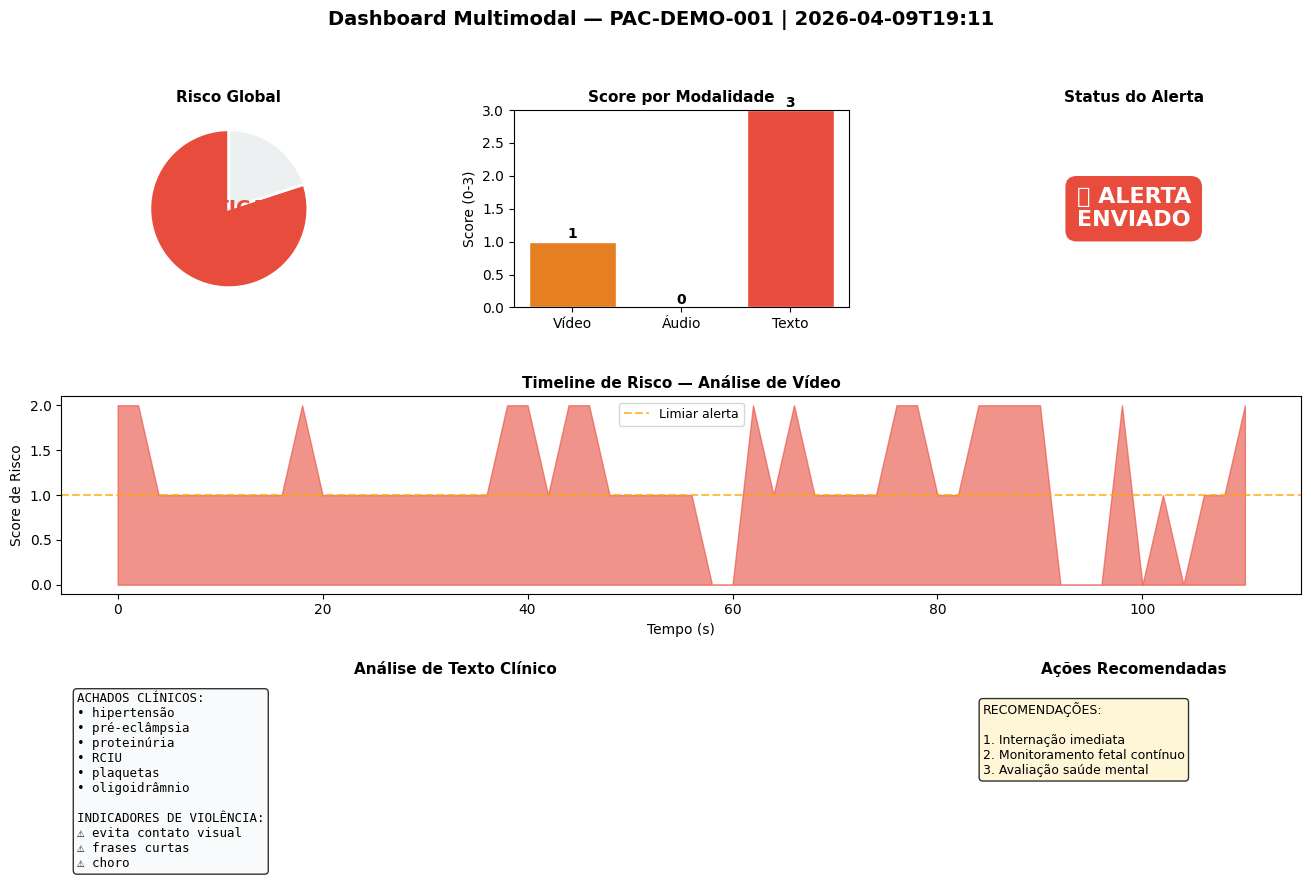

Dashboard salvo em reports/anomalies_examples/dashboard_demo.png


In [11]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

RISK_COLORS = {'low': '#2ecc71', 'medium': '#f39c12', 'high': '#e67e22', 'critical': '#e74c3c'}

# ── 1. Score global (gauge) ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
risk_color = RISK_COLORS[report['overall_risk']]
ax1.pie([report['scores']['total'], 5 - report['scores']['total']],
        colors=[risk_color, '#ecf0f1'], startangle=90,
        wedgeprops={'linewidth': 2, 'edgecolor': 'white'})
ax1.text(0, 0, report['overall_risk'].upper(), ha='center', va='center',
         fontsize=14, fontweight='bold', color=risk_color)
ax1.set_title('Risco Global', fontweight='bold', fontsize=11)

# ── 2. Scores por modalidade ─────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
mods   = ['Vídeo', 'Áudio', 'Texto']
scores = [report['scores']['video'], report['scores']['audio'], report['scores']['text']]
bars   = ax2.bar(mods, scores, color=[RISK_COLORS['high'], RISK_COLORS['medium'], RISK_COLORS['critical']], edgecolor='white')
ax2.set_ylim(0, 3)
ax2.set_title('Score por Modalidade', fontweight='bold', fontsize=11)
ax2.set_ylabel('Score (0-3)')
for bar, val in zip(bars, scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             str(val), ha='center', fontweight='bold')

# ── 3. Alerta ────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.axis('off')
alert_color = '#e74c3c' if report['requires_immediate_attention'] else '#2ecc71'
alert_text  = '🚨 ALERTA\nENVIADO' if report['requires_immediate_attention'] else '✅ SEM\nALERTA'
ax3.text(0.5, 0.5, alert_text, ha='center', va='center', fontsize=16, fontweight='bold',
         color='white', transform=ax3.transAxes,
         bbox=dict(boxstyle='round,pad=0.5', facecolor=alert_color, linewidth=0))
ax3.set_title('Status do Alerta', fontweight='bold', fontsize=11)

# ── 4. Timeline de risco vídeo ───────────────────────────────────
ax4 = fig.add_subplot(gs[1, :])
if not df_video.empty:
    ax4.fill_between(df_video['timestamp_s'], df_video['risk_score'],
                     color='#e74c3c', alpha=0.6)
    ax4.set_ylabel('Score de Risco')
    ax4.axhline(y=1, color='orange', linestyle='--', alpha=0.7, label='Limiar alerta')
    ax4.legend(fontsize=9)
ax4.set_title('Timeline de Risco — Análise de Vídeo', fontweight='bold', fontsize=11)
ax4.set_xlabel('Tempo (s)')

# ── 5. Achados clínicos do texto ─────────────────────────────────
ax5 = fig.add_subplot(gs[2, :2])
ax5.axis('off')
findings_text = '\n'.join([f'• {f}' for f in text_analysis_result.get('findings', [])[:6]])
violence_text = '\n'.join([f'⚠ {v}' for v in text_analysis_result.get('violence_indicators', [])[:3]])
full_text = f'ACHADOS CLÍNICOS:\n{findings_text}\n\nINDICADORES DE VIOLÊNCIA:\n{violence_text}'
ax5.text(0.02, 0.95, full_text, transform=ax5.transAxes, fontsize=9,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#f8f9fa', alpha=0.8))
ax5.set_title('Análise de Texto Clínico', fontweight='bold', fontsize=11)

# ── 6. Recomendações ─────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')
recs = text_analysis_result.get('recommendations', [])[:4]
rec_text = '\n'.join([f'{i+1}. {r}' for i, r in enumerate(recs)])
ax6.text(0.05, 0.9, f'RECOMENDAÇÕES:\n\n{rec_text}',
         transform=ax6.transAxes, fontsize=9,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='#fff3cd', alpha=0.8))
ax6.set_title('Ações Recomendadas', fontweight='bold', fontsize=11)

plt.suptitle(
    f'Dashboard Multimodal — {report["patient_id"]} | {report["timestamp"][:16]}',
    fontsize=14, fontweight='bold'
)
plt.savefig('../reports/anomalies_examples/dashboard_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard salvo em reports/anomalies_examples/dashboard_demo.png')

## 7. Alerta para a Equipe Médica

Simulamos o disparo do alerta para a equipe médica via `src/cloud/alerts.py`.

In [12]:
import logging
logging.basicConfig(level=logging.WARNING)

def send_medical_alert(report: dict) -> bool:
    """Envia alerta à equipe médica. Baseado em src/cloud/alerts.py."""
    if not report.get('requires_immediate_attention'):
        print('Sem necessidade de alerta imediato.')
        return False

    message = (
        f"[{report['timestamp']}] "
        f"ALERTA MÉDICO — Paciente {report['patient_id']} | "
        f"Risco: {report['overall_risk'].upper()} | "
        f"Score total: {report['scores']['total']}/5 | "
        f"Recomendações: {'; '.join(report.get('recommendations', [])[:2])}"
    )

    print('\n' + '='*70)
    print('🚨  ALERTA ENVIADO À EQUIPE MÉDICA  🚨')
    print('='*70)
    print(message)
    print('='*70 + '\n')

    # Em produção: substituir por webhook, email ou integração hospitalar
    webhook_url = os.getenv('ALERT_WEBHOOK_URL')
    if webhook_url:
        import requests
        try:
            requests.post(webhook_url, json={'text': message}, timeout=5)
            print('Webhook enviado com sucesso.')
        except Exception as e:
            print(f'Falha no webhook: {e}')

    return True


alert_sent = send_medical_alert(report)

# Salvar relatório em JSON
report_path = Path('../reports') / f"{report['report_id']}.json"
report_path.parent.mkdir(exist_ok=True)
report_path.write_text(json.dumps(report, indent=2, ensure_ascii=False))
print(f'Relatório salvo em: {report_path}')


🚨  ALERTA ENVIADO À EQUIPE MÉDICA  🚨
[2026-04-09T19:11:37.683692] ALERTA MÉDICO — Paciente PAC-DEMO-001 | Risco: CRITICAL | Score total: 4/5 | Recomendações: Internação imediata; Monitoramento fetal contínuo

Relatório salvo em: ..\reports\RPT-20260409191137.json


## 8. Resumo Final do Pipeline

Visão consolidada de tudo que foi processado neste notebook — adequada para o relatório técnico.

In [13]:
print('\n' + '='*65)
print('  RESUMO DO PIPELINE MULTIMODAL — TECH CHALLENGE FASE 4')
print('='*65)

print(f"""
ENTRADA:
  Vídeo : {VIDEO_SAMPLE.name}
  Áudio : {AUDIO_SAMPLE.name}
  Texto : Laudo clínico simulado ({len(CLINICAL_TEXT)} chars)

PROCESSAMENTO:
  [VÍDEO]
    DeepFace  — {len(emotion_results)} frames analisados
    MediaPipe — {len(pose_results)} poses detectadas
    Fusão     — {sum(1 for v in video_fusion if v['alert'])} alertas de vídeo

  [ÁUDIO]
    Transcrição  — {transcript_result['status']}
    Emoção vocal — {audio_emotion_result['predicted_emotion']}
    Alerta áudio — {audio_emotion_result['alert']}

  [TEXTO]
    Risco clínico — {text_analysis_result.get('risk_level', 'N/A')}
    Achados       — {len(text_analysis_result.get('findings', []))}
    Indicadores   — {len(text_analysis_result.get('violence_indicators', []))} de violência

SAÍDA:
  Risco global  : {report['overall_risk'].upper()}
  Score total   : {report['scores']['total']}/5
  Alerta enviado: {report['alert_generated']}
  Relatório     : {report['report_id']}.json
  Dashboard     : reports/anomalies_examples/dashboard_demo.png
""")

print('='*65)
print('Notebooks concluídos: 01 ✅  02 ✅  03 ✅  04 ✅')
print('Próximo passo: Relatório Técnico + Vídeo de Demonstração')


  RESUMO DO PIPELINE MULTIMODAL — TECH CHALLENGE FASE 4

ENTRADA:
  Vídeo : facial_recognition_activities.mp4
  Áudio : consulta_sample.mp3
  Texto : Laudo clínico simulado (989 chars)

PROCESSAMENTO:
  [VÍDEO]
    DeepFace  — 57 frames analisados
    MediaPipe — 56 poses detectadas
    Fusão     — 49 alertas de vídeo

  [ÁUDIO]
    Transcrição  — success
    Emoção vocal — normal
    Alerta áudio — False

  [TEXTO]
    Risco clínico — critical
    Achados       — 6
    Indicadores   — 4 de violência

SAÍDA:
  Risco global  : CRITICAL
  Score total   : 4/5
  Alerta enviado: True
  Relatório     : RPT-20260409191137.json
  Dashboard     : reports/anomalies_examples/dashboard_demo.png

Notebooks concluídos: 01 ✅  02 ✅  03 ✅  04 ✅
Próximo passo: Relatório Técnico + Vídeo de Demonstração
